In [3]:
import cv2
img_original=cv2.imread("/home/angelika/Desktop/8_term/R_D/General_C/DATA/test_only/8.jpeg", cv2.IMREAD_COLOR)

In [3]:
img_bubbles = cv2.imread("/home/angelika/Desktop/8_term/R_D/General_C/DATA/5.png", cv2.IMREAD_COLOR)
img_spots = cv2.imread("/home/angelika/Desktop/8_term/R_D/General_C/DATA/4.png", cv2.IMREAD_COLOR)
img_spots_big = cv2.imread("/home/angelika/Desktop/8_term/R_D/General_C/DATA/image.jpg", cv2.IMREAD_COLOR)
img_crack = cv2.imread("/home/angelika/Desktop/8_term/R_D/General_C/DATA/6.png", cv2.IMREAD_COLOR)

In [38]:
img_original = cv2.cvtColor(img_original, cv2.COLOR_RGB2BGR)
img_bubbles = cv2.cvtColor(img_bubbles, cv2.COLOR_BGR2RGB)
img_spots = cv2.cvtColor(img_spots, cv2.COLOR_BGR2RGB)
img_spots_big = cv2.cvtColor(img_spots_big, cv2.COLOR_BGR2RGB)
img_crack = cv2.cvtColor(img_crack, cv2.COLOR_BGR2RGB)

rescale = cv2.resize(img_spots_big, (img_bubbles.shape[1],img_bubbles.shape[0]))

In [39]:
import numpy as np
top_row = np.hstack((cv2.resize(img_original, (img_bubbles.shape[1],img_bubbles.shape[0])), img_bubbles, img_spots, rescale, img_crack))

In [17]:
img_original.shape

(243, 207, 3)

In [25]:
img_spots_big.shape

(960, 768, 3)

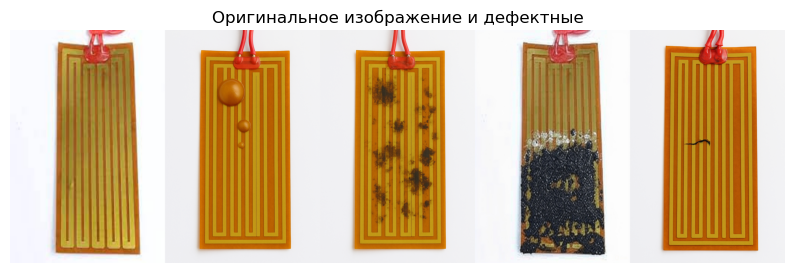

In [41]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 10))
plt.imshow(top_row)
plt.axis('off')
plt.title('Оригинальное изображение и дефектные')
plt.show()

In [56]:
def compute_phase_correlation_spectrum(img1, img2):
    """
    Фазовая корреляция между двумя изображениями.
    Возвращает: сдвиг (dx, dy) и значение корреляции (peak value).
    """
    # Переводим изображения в оттенки серого
    gray1 = cv2.cvtColor(img1, cv2.COLOR_RGB2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_RGB2GRAY)
    rescale1 = cv2.resize(gray1, (gray2.shape[1],gray2.shape[0]))
    

    # Приводим к float32
    rescale1 = np.float32(rescale1)
    gray2 = np.float32(gray2)
    
    # Вычисляем фазовую корреляцию
    (shift_x, shift_y), response = cv2.phaseCorrelate(rescale1, gray2)
    #print((shift_x, shift_y), response)
    f1 = np.fft.fft2(rescale1)
    f2 = np.fft.fft2(gray2)

    conj_f2 = np.conj(f2)
    R = (f1 * conj_f2) / (np.abs(f1 * conj_f2)+1e-8)
    r = np.fft.ifft2(R)
    r = np.abs(r)

    r = np.fft.fftshift(r)

    r_norm = cv2.normalize(r, None, 0, 255, cv2.NORM_MINMAX)
    r_norm = np.uint8(r_norm)

    return r_norm, (shift_x, shift_y), response

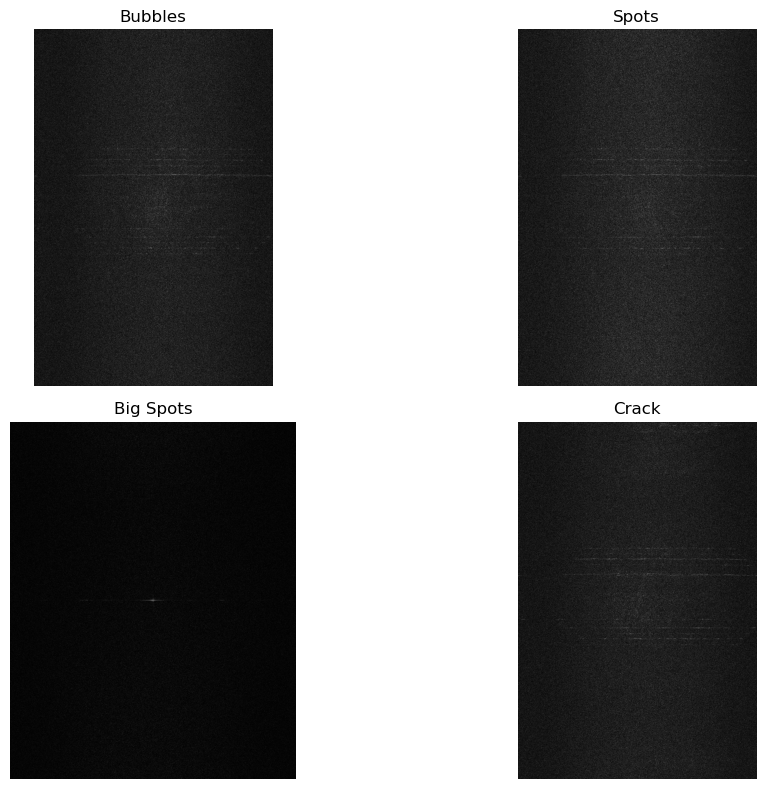

In [59]:
spectrum_bubbles, shift_bubbles, response_bubbles = compute_phase_correlation_spectrum(img_original, img_bubbles)
spectrum_spots, shift_spots, response_spots = compute_phase_correlation_spectrum(img_original, img_spots)
spectrum_spots_big, shift_spots_big, response_spots_big = compute_phase_correlation_spectrum(img_original, img_spots_big)
spectrum_crack, shift_crack, response_crack = compute_phase_correlation_spectrum(img_original, img_crack)


plt.figure(figsize=(12, 8))
titles = ['Bubbles', 'Spots', 'Big Spots', 'Crack']
spectra = [spectrum_bubbles, spectrum_spots, spectrum_spots_big, spectrum_crack]

for i, spectrum in enumerate(spectra):
    plt.subplot(2, 2, i+1)
    plt.imshow(spectrum, cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [74]:
def compute_difference(img1, img2):
    gray1 = cv2.cvtColor(img1, cv2.COLOR_RGB2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_RGB2GRAY)
    gray1 = cv2.resize(gray1, (gray2.shape[1], gray2.shape[0]))

    # Абсолютная разность
    diff = cv2.absdiff(gray1, gray2)

    # Побитовая операция для усиления (если надо)
    # diff = cv2.bitwise_xor(gray1, gray2)

    # Порог для выделения существенных различий
    _, thresh = cv2.threshold(diff, 30, 255, cv2.THRESH_BINARY)

    # Немного морфологии для удаления шума
    kernel = np.ones((3, 3), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

    # Поиск контуров
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    output = img2.copy()
    cv2.drawContours(output, contours, -1, (0, 0, 255), 2)

    return output


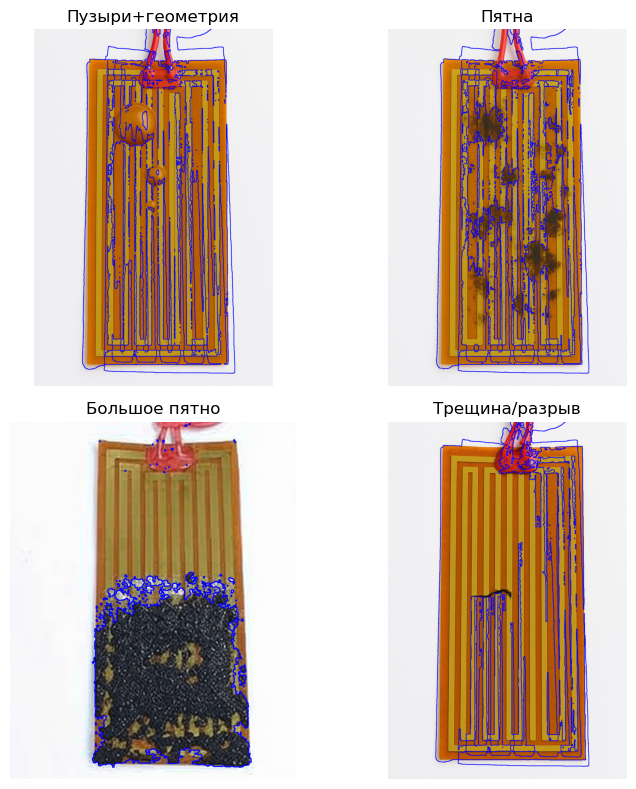

In [77]:
plt.figure(figsize=(8, 8))
images = [img_bubbles, img_spots, img_spots_big, img_crack]
titles = ['Пузыри+геометрия', 'Пятна', 'Большое пятно', 'Трещина/разрыв']
diff = []
for i, img in enumerate(images):
    difference = compute_difference(img_original, img)
    diff[i] = diff.append(difference)
    plt.subplot(2, 2, i+1)
    plt.imshow(difference, cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [38]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def find_frame_by_mask(img, angle_tolerance_h=5, angle_tolerance_v=3, min_contour_width=80):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    out = img.copy()
    print(img.shape)
    
    binary = cv2.adaptiveThreshold(
        gray,
        255,
        cv2.ADAPTIVE_THRESH_MEAN_C,
        cv2.THRESH_BINARY_INV,  
        11, 2
    )

    # Немного размываем чтобы убрать шум
    blurred = cv2.GaussianBlur(binary, (5, 5), 0)

    # Поиск границ через Canny
    edges = cv2.Canny(blurred, 100, 150, apertureSize=3)
    
    # Отображение изображения (используйте imshow перед show)
    plt.imshow(cv2.cvtColor(edges, cv2.COLOR_GRAY2BGR))
    plt.title("Edges after Canny")
    plt.axis('off')
    plt.show()


    # Поиск контуров по готовой маске
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    object_contours = []
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        if w >= min_contour_width and h >= min_contour_width:
            object_contours.append(cnt)

    if not object_contours:
        print("Не найдены подходящие контуры объекта!")
        return None

    # Объединяем все подходящие контуры в одну маску
    mask = np.zeros_like(gray)
    cv2.drawContours(mask, object_contours, -1, (255), thickness=cv2.FILLED)

    # Теперь снова находим экстремальные точки по маске
    ys, xs = np.where(mask == 255)
    x_min, x_max = np.min(xs), np.max(xs)
    y_min, y_max = np.min(ys), np.max(ys)

    # Нарисуем прямоугольник вокруг итогового объекта
    cv2.rectangle(out, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)

    # Показ
    plt.figure(figsize=(10, 10))
    plt.title("Объект после фильтрации по маске")
    plt.imshow(out)
    plt.axis('off')
    plt.show()

    return x_min, y_min, x_max, y_max


(243, 207, 3)


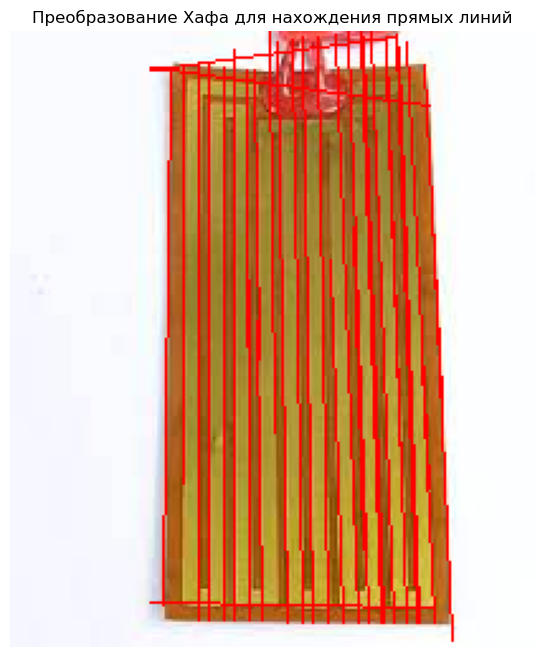

(55, 0, 174, 240)

In [39]:
find_frame(img_original)

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def find_frame(img, angle_tolerance_h=25, angle_tolerance_v=3, min_line_length_filter=70):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    out = img.copy()
    print(img.shape)
    
    binary = cv2.adaptiveThreshold(
        gray,
        255,
        cv2.ADAPTIVE_THRESH_MEAN_C,
        cv2.THRESH_BINARY_INV,
        11, 2
    )

    blurred = cv2.GaussianBlur(binary, (5, 5), 0)
    edges = cv2.Canny(blurred, 120, 150, apertureSize=3)

    lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=30, minLineLength=70, maxLineGap=50)

    filtered_lines = []
    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]

            angle = np.degrees(np.arctan2((y2 - y1), (x2 - x1)))
            line_length = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)

            if ((abs(angle) < angle_tolerance_h) or (abs(abs(angle) - 90) < angle_tolerance_v)) and (line_length > min_line_length_filter):
                filtered_lines.append((x1, y1, x2, y2))

    if not filtered_lines:
        print("Не найдены подходящие линии!")
        return None

    # Разделяем линии на горизонтальные и вертикальные
    horizontal_lines = []
    vertical_lines = []

    for line in filtered_lines:
        x1, y1, x2, y2 = line
        angle = np.degrees(np.arctan2((y2 - y1), (x2 - x1)))

        if abs(angle) < angle_tolerance_h:
            horizontal_lines.append(line)
        elif abs(abs(angle) - 90) < angle_tolerance_v:
            vertical_lines.append(line)

    if not horizontal_lines or not vertical_lines:
        print("Недостаточно линий для определения рамки!")
        return None

    # Находим крайние линии отдельно
    top_line = min(horizontal_lines, key=lambda line: min(line[1], line[3]))
    bottom_line = max(horizontal_lines, key=lambda line: max(line[1], line[3]))
    left_line = min(vertical_lines, key=lambda line: min(line[0], line[2]))
    right_line = max(vertical_lines, key=lambda line: max(line[0], line[2]))

    # Нарисуем линии
    thickness = 2
    for line in [top_line, bottom_line, left_line, right_line]:
        x1, y1, x2, y2 = line
        cv2.line(out, (x1, y1), (x2, y2), (255, 0, 0), thickness)

    # Находим координаты рамки
    all_points = np.array([
        [top_line[0], top_line[1]], [top_line[2], top_line[3]],
        [bottom_line[0], bottom_line[1]], [bottom_line[2], bottom_line[3]],
        [left_line[0], left_line[1]], [left_line[2], left_line[3]],
        [right_line[0], right_line[1]], [right_line[2], right_line[3]],
    ])

    x_min = np.min(all_points[:, 0])
    x_max = np.max(all_points[:, 0])
    y_min = np.min(all_points[:, 1])
    y_max = np.max(all_points[:, 1])

    print(all_points)

    # Показ
    plt.figure(figsize=(8, 8))
    plt.title("4 крайние линии (рамка)")
    out = cv2.cvtColor(out, cv2.COLOR_BGR2RGB)
    plt.imshow(out)
    plt.axis('off')
    plt.show()

    return x_min, y_min, x_max, y_max


(243, 207, 3)
[[ 55  16]
 [163  14]
 [ 54 232]
 [176 234]
 [ 60 229]
 [ 63  16]
 [169 119]
 [174 240]]


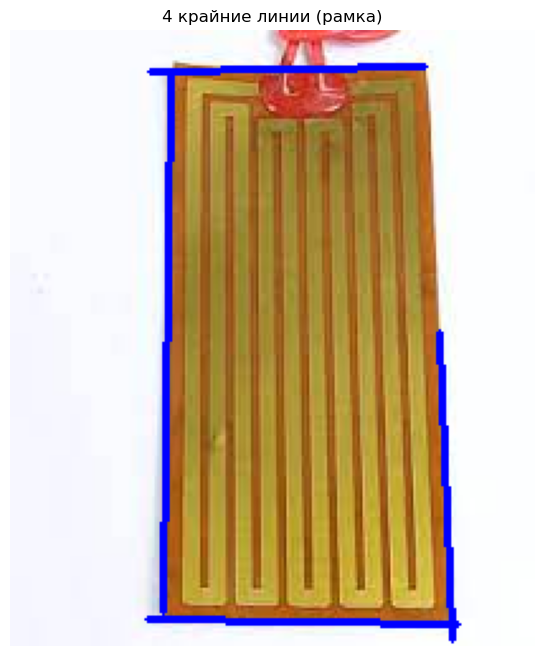

(54, 14, 176, 240)

In [5]:
find_frame(img_original) 
# w = 170
# h = 215

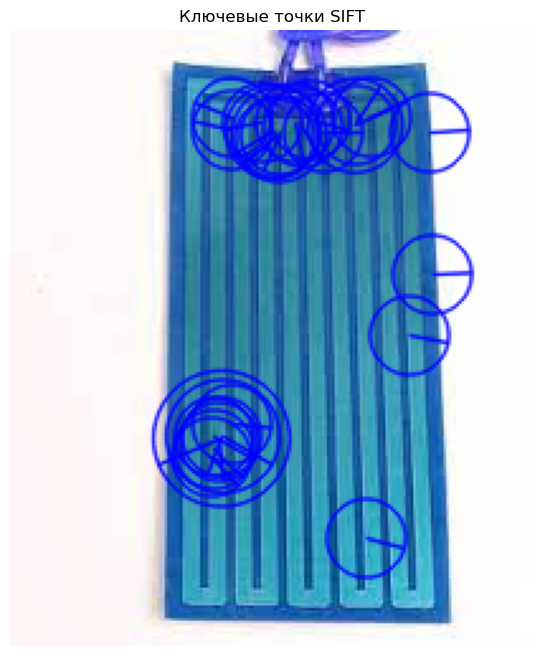

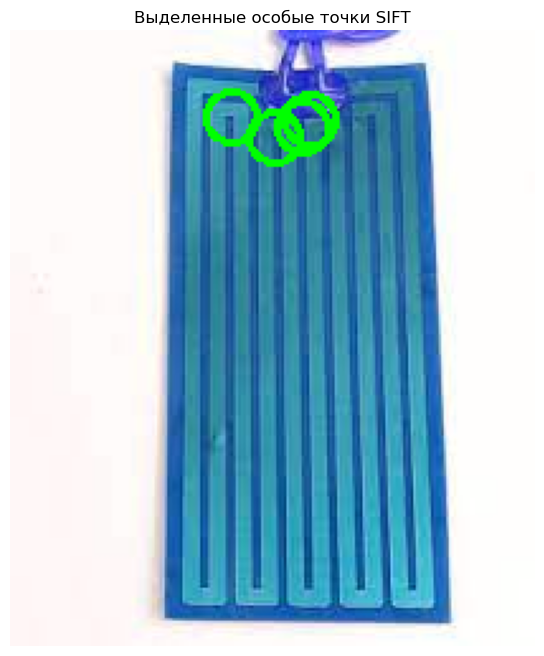

Найденные особые точки: [(87, 34), (118, 35), (115, 38), (104, 42)]


In [3]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def find_frame_with_sift(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    out = img.copy()

    # Создание объекта SIFT
    sift = cv2.ORB_create()

    # Нахождение ключевых точек и дескрипторов
    keypoints, descriptors = sift.detectAndCompute(gray, None)

    # Отображаем ключевые точки на изображении
    img_with_keypoints = cv2.drawKeypoints(img, keypoints, None, (0, 0, 255), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    
    # Показ изображения с ключевыми точками
    plt.figure(figsize=(8, 8))
    plt.title("Ключевые точки SIFT")
    plt.imshow(img_with_keypoints)
    plt.axis('off')
    plt.show()

    # Сортируем ключевые точки по их яркости (можно использовать другие метрики)
    sorted_keypoints = sorted(keypoints, key=lambda x: x.response, reverse=True)

    # Выбираем несколько самых ярких ключевых точек для анализа
    top_keypoints = sorted_keypoints[:4]

    points = []
    for kp in top_keypoints:
        points.append((int(kp.pt[0]), int(kp.pt[1])))  # x, y координаты точки

    # Рисуем круги вокруг найденных точек
    for point in points:
        cv2.circle(out, point, 10, (0, 255, 0), 2)

    # Показ результата
    plt.figure(figsize=(8, 8))
    plt.title("Выделенные особые точки SIFT")
    plt.imshow(out)
    plt.axis('off')
    plt.show()

    # Возвращаем координаты найденных точек
    return points

# Пример использования:
points = find_frame_with_sift(img_original)
print(f"Найденные особые точки: {points}")
